<a href="https://colab.research.google.com/github/samyssr/machine-learning-labs/blob/main/Random_Forest_and_XGBoost_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating and measureing the relative performances of Random Forest and XGBoost regression models for predicting house prices using the California Housing Dataset aiming speed and accuracy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

In [ ]:
# Load the California Housing dataset from URL
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UZPRFNucrENAFm25csq6eQ/California-housing.csv")


In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
X = df.drop(columns=["Target"])
y = df["Target"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
N_observations, N_features = df.shape

In [ ]:
print('Number of Observations: ' + str(N_observations))
print('Number of Features: ' + str(N_features))

Number of Observations: 20640
Number of Features: 9


Defining the number of base estimators, or individual trees, to be used in each model,

In [ ]:
n_estimators=100
rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
xgb = XGBRegressor(n_estimators=n_estimators, random_state=42)

In [ ]:
# Fit models
# Measure training time for Random Forest
start_time_rf = time.time()
rf.fit(X_train, y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf

# Measure training time for XGBoost
start_time_xgb = time.time()
xgb.fit(X_train, y_train)
end_time_xgb = time.time()
xgb_train_time = end_time_xgb - start_time_xgb

In [ ]:
# Measure prediction time for Random Forest
start_time_rf = time.time()
y_pred_rf = rf.predict(X_test)
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf

# Measure prediction time for Random Forest
start_time_rf = time.time()
y_pred_rf = rf.predict(X_test)
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf

# Measure prediciton time for XGBoost
start_time_xgb = time.time()
y_pred_xgb = xgb.predict(X_test)
end_time_xgb = time.time()
xgb_pred_time = end_time_xgb - start_time_xgb

In [ ]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [ ]:
print(f"Tempo de Treino RF:  {rf_train_time:.2f} s")
print(f"Tempo de Treino XGB: {xgb_train_time:.2f} s")

Tempo de Treino RF:  19.87 s
Tempo de Treino XGB: 0.34 s


Predição com Medição de Tempo

In [ ]:
# Predição Random Forest
rf_pred_start = time.time()
rf_predictions = rf.predict(X_test)
rf_pred_time = time.time() - rf_pred_start

# Predição XGBoost
xgb_pred_start = time.time()
xgb_predictions = xgb.predict(X_test)
xgb_pred_time = time.time() - xgb_pred_start

print(f"Tempo de Predição RF:  {rf_pred_time:.4f} s")
print(f"Tempo de Predição XGB: {xgb_pred_time:.4f} s")

Tempo de Predição RF:  0.1525 s
Tempo de Predição XGB: 0.0175 s


In [ ]:
# 1. Métricas do Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

# 2. Métricas do XGBoost
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

# 3. Exibição dos resultados
print("=== Desempenho dos Modelos ===")
print(f"Random Forest -> MSE: {rf_mse:.4f} | R²: {rf_r2:.4f}")
print(f"XGBoost       -> MSE: {xgb_mse:.4f} | R²: {xgb_r2:.4f}")

=== Desempenho dos Modelos ===
Random Forest -> MSE: 0.2554 | R²: 0.8051
XGBoost       -> MSE: 0.2140 | R²: 0.8367


In [ ]:
print("=== Comparativo de Tempo (Segundos) ===")
print(f"Random Forest -> Treino: {rf_train_time:.3f}s | Predição: {rf_pred_time:.4f}s")
print(f"XGBoost       -> Treino: {xgb_train_time:.3f}s | Predição: {xgb_pred_time:.4f}s")

=== Comparativo de Tempo (Segundos) ===
Random Forest -> Treino: 19.872s | Predição: 0.1525s
XGBoost       -> Treino: 0.335s | Predição: 0.0175s


In [ ]:
# 1. Calcula o desvio padrão dos valores reais de teste
std_y = np.std(y_test)

plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

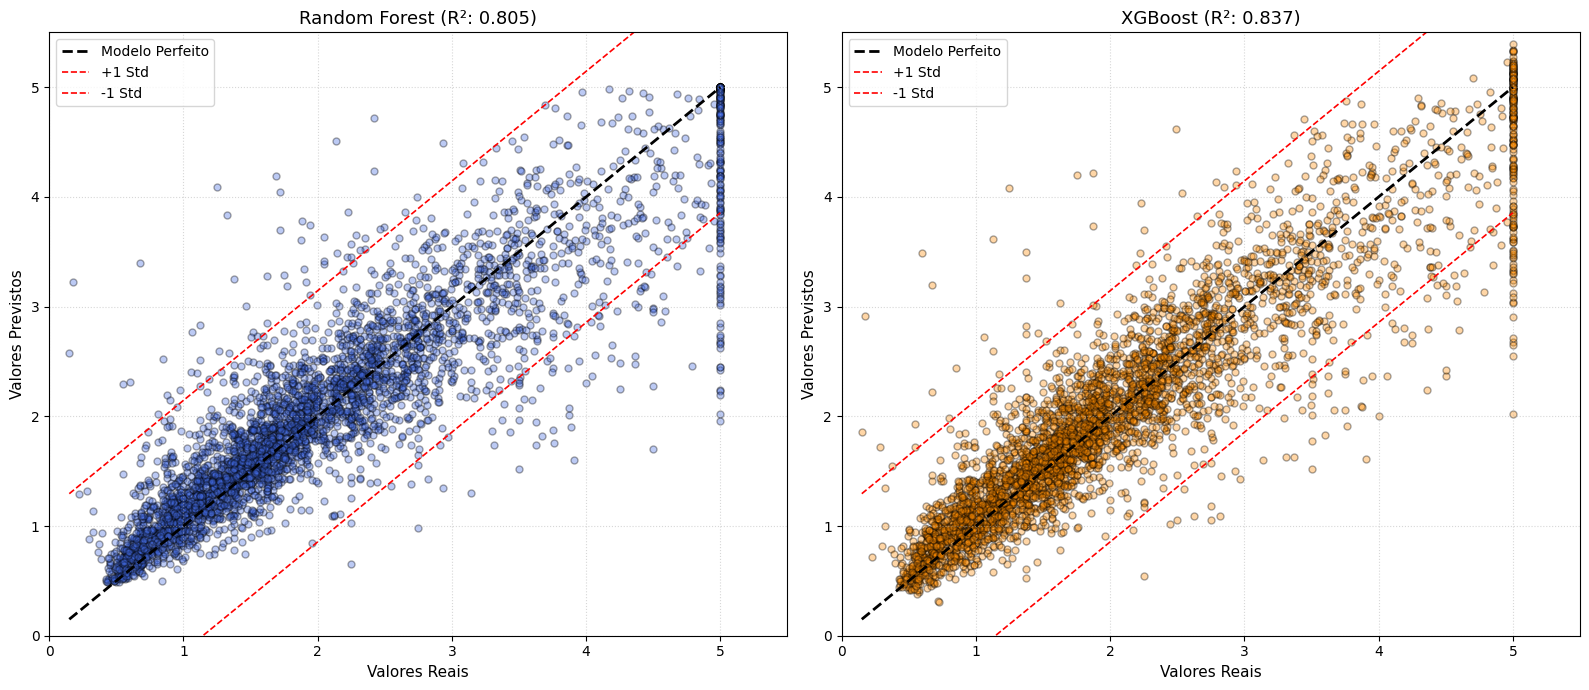

In [ ]:
plt.figure(figsize=(16, 7))

# 1. Random Forest
plt.subplot(1, 2, 1)
plt.scatter(y_test, rf_predictions, alpha=0.35, color="royalblue", ec='k', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Modelo Perfeito")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1.2, label="+1 Std")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1.2, label="-1 Std")
plt.xlim(0, 5.5)
plt.ylim(0, 5.5)
plt.title("Random Forest (R²: 0.805)", fontsize=13)
plt.xlabel("Valores Reais", fontsize=11)
plt.ylabel("Valores Previstos", fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

# 2. XGBoost
plt.subplot(1, 2, 2)
plt.scatter(y_test, xgb_predictions, alpha=0.35, color="darkorange", ec='k', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Modelo Perfeito")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1.2, label="+1 Std")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1.2, label="-1 Std")
plt.xlim(0, 5.5)
plt.ylim(0, 5.5)
plt.title("XGBoost (R²: 0.837)", fontsize=13)
plt.xlabel("Valores Reais", fontsize=11)
plt.ylabel("Valores Previstos", fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()